# Benchmark công thức $C_{ij}$ với các phương pháp phân cụm khác

Mục tiêu: đánh giá **Product-$C_{ij}$ + Louvain** so với các baseline được tuning riêng, không bắt các thuật toán dùng chung loại tham số.

- Development: `run_001`–`run_020` (kiểm tra dữ liệu/code).
- Calibration: `run_021`–`run_040` (chọn cấu hình riêng bằng mean ARI).
- Benchmark test: `run_041`–`run_080` (khóa cấu hình rồi chấm đúng một lượt).

Mọi phương pháp chỉ nhận `algorithm_input.json`. Trong test, toàn bộ prediction được tạo xong trước khi mở `ground_truth.json`. `latent_incidents.json` và `observable_reports.json` không được đọc. Vì kết quả tổng hợp 80 run đã từng được quan sát trong quá trình phát triển, 40 run cuối là **benchmark test split**, không được gọi là held-out hoàn toàn chưa từng quan sát.


In [1]:
from google.colab import drive
from pathlib import Path
import zipfile

drive.mount('/content/drive')
DRIVE_DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/data')
DATA_ZIP_NAME = 'flood_hybrid_EMSR848_80_runs (1).zip'
DATA_ZIP = DRIVE_DATA_DIR / DATA_ZIP_NAME
DATA_WORK = Path('/content/cij_baseline_benchmark_data')
RESULTS_ROOT = DRIVE_DATA_DIR / 'cij_baseline_benchmark_results'

assert DATA_ZIP.is_file(), f'Không tìm thấy {DATA_ZIP}'
if not list(DATA_WORK.rglob('run_001/algorithm_input.json')):
    DATA_WORK.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(DATA_ZIP) as archive:
        archive.extractall(DATA_WORK)
run_dirs = sorted(path.parent for path in DATA_WORK.rglob('run_*/algorithm_input.json'))
assert len(run_dirs) == 80 and run_dirs[0].name == 'run_001' and run_dirs[-1].name == 'run_080'
DEV_RUNS, CAL_RUNS, TEST_RUNS = run_dirs[:20], run_dirs[20:40], run_dirs[40:]
assert not (set(DEV_RUNS) & set(CAL_RUNS) or set(DEV_RUNS) & set(TEST_RUNS) or set(CAL_RUNS) & set(TEST_RUNS))
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
print('Split:', len(DEV_RUNS), len(CAL_RUNS), len(TEST_RUNS))
print('Calibration:', CAL_RUNS[0].name, '→', CAL_RUNS[-1].name)
print('Test:', TEST_RUNS[0].name, '→', TEST_RUNS[-1].name)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Split: 20 20 40
Calibration: run_021 → run_040
Test: run_041 → run_080


In [2]:
# Cài dependency và tự restart kernel đúng một lần nếu cần thay NumPy.
import importlib.metadata as package_metadata
import os, subprocess, sys
from pathlib import Path
assert sys.version_info[:2] == (3, 12), 'Hãy chọn runtime Python 3.12.'
REQUIRED = {
    'numpy':'2.5.1', 'pandas':'3.0.3', 'matplotlib':'3.11.0',
    'networkx':'3.6.1', 'python-louvain':'0.16',
    'scikit-learn':'1.9.0', 'scipy':'1.18.0',
    'igraph':'1.0.0', 'leidenalg':'0.12.0',
}
MARKER = Path('/content/.cij_baseline_dependencies_v1')
if not MARKER.is_file():
    specs = [f'{name}=={version}' for name, version in REQUIRED.items()]
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade',
                    '--upgrade-strategy', 'only-if-needed', *specs], check=True)
    MARKER.write_text('ready', encoding='utf-8')
    print('Đã cài xong; Colab tự restart. Kết nối lại rồi Run all lần nữa.')
    os.kill(os.getpid(), 9)
installed = {name: package_metadata.version(name) for name in REQUIRED}
assert installed == REQUIRED, f'Phiên bản không khớp: {installed}'
subprocess.run([sys.executable, '-c', 'import numpy,scipy,sklearn,community,igraph,leidenalg'], check=True)
print('PASS dependencies:', installed)


PASS dependencies: {'numpy': '2.5.1', 'pandas': '3.0.3', 'matplotlib': '3.11.0', 'networkx': '3.6.1', 'python-louvain': '0.16', 'scikit-learn': '1.9.0', 'scipy': '1.18.0', 'igraph': '1.0.0', 'leidenalg': '0.12.0'}


## Phương pháp và ngân sách tuning

| ID | Vai trò | Số cấu hình |
|---|---|---:|
| `product_cij_louvain` | phương pháp đề xuất | 16 |
| `additive_cij_louvain` | đối chứng phép cộng cùng $G,T,C$ | 16 |
| `convex_cij_louvain` | hỗn hợp cộng chuẩn hóa linh hoạt | 12 |
| `st_dbscan` | baseline không–thời gian | 12 |
| `dbscan_all` | DBSCAN trên mọi feature quan sát | 12 |
| `hdbscan_all` | HDBSCAN trên mọi feature quan sát | 16 |
| `spatial_agglomerative` | phân cụm phân cấp có connectivity địa lý | 12 |
| `coordinate_kmeans` | diagnostic chỉ dùng tọa độ | 3 |
| `product_cij_leiden` | cùng graph đề xuất, đổi Louvain thành Leiden | 4 resolution |

Số cấu hình không hoàn toàn bằng nhau vì mỗi thuật toán có số núm khác nhau; mọi grid đều nhỏ, được ghi rõ và chạy hết, không dừng khi thấy kết quả thuận lợi. K-Means là diagnostic yếu, không phải đối thủ tương đương.


In [3]:
import itertools, json, math, time
from collections import Counter
from datetime import datetime

import igraph as ig
import leidenalg
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from community import community_louvain
from scipy.sparse import csr_matrix
from scipy.stats import wilcoxon
from sklearn.cluster import AgglomerativeClustering, DBSCAN, HDBSCAN, KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import RobustScaler, StandardScaler

TAU_F, TAU_E = 0.25, 0.35
BETA, GAMMA = 0.5, 0.5
FORMULA_VERSION = 'paper-missing-aware-cij-v1'

def read_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))

def load_input(run_dir):
    payload = read_json(run_dir / 'algorithm_input.json')
    rows = payload['reports']
    lat = np.radians(np.array([float(r['lat']) for r in rows]))
    lng = np.radians(np.array([float(r['lng']) for r in rows]))
    lat0, lng0 = np.median(lat), np.median(lng)
    east = 6_371_000.0 * np.cos(lat0) * (lng - lng0)
    north = 6_371_000.0 * (lat - lat0)
    minute = np.array([datetime.fromisoformat(r['created_at']).timestamp()/60 for r in rows])
    minute = minute - minute.min()
    flood = np.array([float(r['flood']) for r in rows])
    urgency = np.array([float(r['urgency']) for r in rows])
    obs_f = np.array(['flood' not in r.get('missing_fields', []) for r in rows])
    obs_e = np.array(['urgency' not in r.get('missing_fields', []) for r in rows])
    return {'dataset_id':payload['dataset_id'], 'seed':int(payload['seed']),
            'event_id':[r['event_id'] for r in rows], 'lat_rad':lat, 'lng_rad':lng,
            'east':east, 'north':north, 'minute':minute, 'flood':flood,
            'urgency':urgency, 'obs_f':obs_f, 'obs_e':obs_e}

def load_truth(run_dir, event_ids):
    payload = read_json(run_dir / 'ground_truth.json')
    by_id = {r['event_id']:int(r['gt_cluster']) for r in payload['report_labels']}
    assert set(by_id) == set(event_ids)
    return np.array([by_id[eid] for eid in event_ids])

def pair_matrices(x):
    lat,lng=x['lat_rad'],x['lng_rad']
    dlat=lat[:,None]-lat[None,:]; dlng=lng[:,None]-lng[None,:]
    hav=np.sin(dlat/2)**2+np.cos(lat)[:,None]*np.cos(lat)[None,:]*np.sin(dlng/2)**2
    distance=2*6_371_000.0*np.arcsin(np.sqrt(np.clip(hav,0,1)))
    dt=np.abs(x['minute'][:,None]-x['minute'][None,:])
    i_f=(x['obs_f'][:,None]&x['obs_f'][None,:]).astype(float)
    i_e=(x['obs_e'][:,None]&x['obs_e'][None,:]).astype(float)
    m=i_f+i_e
    cij=(m/2)*np.exp(-i_f*np.abs(x['flood'][:,None]-x['flood'][None,:])/TAU_F
                        -i_e*np.abs(x['urgency'][:,None]-x['urgency'][None,:])/TAU_E)
    cij[m==0]=0; np.fill_diagonal(cij,0)
    return distance,dt,cij

def threshold_knn(w, quantile, knn):
    out=w.copy(); np.fill_diagonal(out,0)
    values=out[np.triu_indices(len(out),1)]; values=values[values>0]
    theta=float(np.quantile(values,quantile)) if len(values) else math.inf
    out[out<=theta]=0
    if 0<knn<len(out):
        mask=np.zeros_like(out,dtype=bool)
        for i,row in enumerate(out):
            top=np.argpartition(row,-knn)[-knn:] if np.count_nonzero(row)>knn else np.nonzero(row)[0]
            mask[i,top]=True
        out=np.where(mask|mask.T,out,0)
    np.fill_diagonal(out,0); return out

def louvain(w,resolution):
    g=nx.Graph(); g.add_nodes_from(range(len(w)))
    a,b=np.nonzero(np.triu(w,1)); g.add_weighted_edges_from((int(i),int(j),float(w[i,j])) for i,j in zip(a,b))
    if not g.number_of_edges(): return np.arange(len(w))
    part=community_louvain.best_partition(g,weight='weight',resolution=resolution,random_state=42)
    return np.array([part.get(i,i) for i in range(len(w))])

def leiden(w,resolution):
    a,b=np.nonzero(np.triu(w,1)); edges=list(zip(a.tolist(),b.tolist()))
    if not edges:return np.arange(len(w))
    g=ig.Graph(n=len(w),edges=edges); g.es['weight']=[float(w[i,j]) for i,j in edges]
    part=leidenalg.find_partition(g,leidenalg.RBConfigurationVertexPartition,
        weights='weight',resolution_parameter=resolution,seed=42)
    labels=np.zeros(len(w),dtype=int)
    for cid,members in enumerate(part): labels[list(members)]=cid
    return labels

def scaled_features(x,scaler):
    raw=np.column_stack([x['east'],x['north'],x['minute'],x['flood'],x['urgency']])
    return (RobustScaler() if scaler=='robust' else StandardScaler()).fit_transform(raw)

# Unit test bắt buộc cho ba nhánh m_ij=2,1,0 của công thức paper.
toy={'lat_rad':np.zeros(4),'lng_rad':np.zeros(4),'minute':np.zeros(4),
     'flood':np.array([.2,.5,.5,.5]),'urgency':np.array([.8,.1,.1,.1]),
     'obs_f':np.array([True,True,True,False]),'obs_e':np.array([True,True,False,False])}
_,_,toy_cij=pair_matrices(toy)
assert np.isclose(toy_cij[0,1],math.exp(-.3/TAU_F-.7/TAU_E))
assert np.isclose(toy_cij[0,2],.5*math.exp(-.3/TAU_F))
assert toy_cij[0,3]==0.0
print('PASS C_ij: đúng các nhánh m_ij = 2, 1, 0')


PASS C_ij: đúng các nhánh m_ij = 2, 1, 0


In [4]:
def predict(method,x,pairs,cfg,selected_product=None):
    distance,dt,cij=pairs
    if method in {'product_cij_louvain','additive_cij_louvain','convex_cij_louvain'}:
        geo=np.exp(-(distance**2)/(2*cfg.get('sigma',900)**2))
        temp=np.exp(-dt/cfg.get('tau_t',60))
        if method=='product_cij_louvain': w=geo*(BETA*temp+GAMMA*cij)
        elif method=='additive_cij_louvain': w=cfg['alpha']*geo+BETA*temp+GAMMA*cij
        else:
            weights=np.array(cfg['mix']); w=weights[0]*geo+weights[1]*temp+weights[2]*cij
        return louvain(threshold_knn(w,cfg['q'],cfg['knn']),cfg.get('resolution',1.2))
    if method=='product_cij_leiden':
        base=selected_product; geo=np.exp(-(distance**2)/(2*base['sigma']**2)); temp=np.exp(-dt/base['tau_t'])
        w=threshold_knn(geo*(BETA*temp+GAMMA*cij),base['q'],base['knn'])
        return leiden(w,cfg['resolution'])
    if method=='st_dbscan':
        dis=np.maximum(distance/cfg['spatial_eps'],dt/cfg['temporal_eps']); np.fill_diagonal(dis,0)
        return DBSCAN(eps=1.0,min_samples=cfg['min_samples'],metric='precomputed').fit_predict(dis)
    if method=='dbscan_all':
        return DBSCAN(eps=cfg['eps'],min_samples=cfg['min_samples']).fit_predict(scaled_features(x,cfg['scaler']))
    if method=='hdbscan_all':
        return HDBSCAN(min_cluster_size=cfg['min_cluster_size'],min_samples=cfg['min_samples']).fit_predict(scaled_features(x,cfg['scaler']))
    if method=='spatial_agglomerative':
        connectivity=csr_matrix((distance<=cfg['radius']).astype(int)); features=scaled_features(x,'standard')
        return AgglomerativeClustering(n_clusters=cfg['k'],linkage='ward',connectivity=connectivity).fit_predict(features)
    if method=='coordinate_kmeans':
        return KMeans(n_clusters=cfg['k'],n_init=10,random_state=42).fit_predict(np.column_stack([x['east'],x['north']]))
    raise ValueError(method)

GRIDS={
 'product_cij_louvain':[dict(sigma=s,tau_t=t,q=q,knn=k,resolution=1.2) for s,t,q,k in itertools.product([700,1200],[30,60],[.90,.95],[8,16])],
 'additive_cij_louvain':[dict(alpha=a,sigma=s,tau_t=60,q=q,knn=k,resolution=1.2) for a,s,q,k in itertools.product([1/3,1.0],[700,1200],[.90,.95],[8,16])],
 'convex_cij_louvain':[dict(mix=m,sigma=900,tau_t=60,q=q,knn=k,resolution=1.2) for m,q,k in itertools.product([(1/3,1/3,1/3),(.6,.2,.2),(.2,.4,.4)],[.90,.95],[8,16])],
 'st_dbscan':[dict(spatial_eps=s,temporal_eps=t,min_samples=m) for s,t,m in itertools.product([800,1200,1800],[60,120],[3,5])],
 'dbscan_all':[dict(eps=e,min_samples=m,scaler=s) for e,m,s in itertools.product([.35,.6,1.0],[3,5],['standard','robust'])],
 'hdbscan_all':[dict(min_cluster_size=c,min_samples=m,scaler=s) for c,m,s in itertools.product([3,5,8,12],[None,3],['standard','robust'])],
 'spatial_agglomerative':[dict(radius=r,k=k) for r,k in itertools.product([800,1200,1800,2500],[13,16,20])],
 'coordinate_kmeans':[dict(k=k) for k in [13,16,20]],
}
print({method:len(grid) for method,grid in GRIDS.items()})


{'product_cij_louvain': 16, 'additive_cij_louvain': 16, 'convex_cij_louvain': 12, 'st_dbscan': 12, 'dbscan_all': 12, 'hdbscan_all': 16, 'spatial_agglomerative': 12, 'coordinate_kmeans': 3}


In [5]:
def quality(labels,truth):
    keep=truth>=0
    return float(adjusted_rand_score(truth[keep],labels[keep]))

# Calibration label-aware: chạy hết grid và chọn mean ARI cao nhất; tie-break bằng std rồi JSON config.
cal_data=[]
for run_dir in CAL_RUNS:
    x=load_input(run_dir); pairs=pair_matrices(x); truth=load_truth(run_dir,x['event_id'])
    cal_data.append((run_dir.name,x,pairs,truth))

selected={}; tuning_rows=[]
for method,grid in GRIDS.items():
    print('Tuning',method,len(grid),'configs')
    candidates=[]
    for ci,cfg in enumerate(grid,1):
        scores=[quality(predict(method,x,pairs,cfg),truth) for _,x,pairs,truth in cal_data]
        row={'method':method,'config_index':ci,'config_json':json.dumps(cfg,sort_keys=True),
             'mean_ari':float(np.mean(scores)),'std_ari':float(np.std(scores,ddof=1))}
        candidates.append((row,cfg)); tuning_rows.append(row)
    best=min(candidates,key=lambda item:(-item[0]['mean_ari'],item[0]['std_ari'],item[0]['config_json']))
    selected[method]=best[1]; print(' selected',best[0])

# Leiden dùng đúng graph product đã chọn, chỉ tuning partition resolution.
leiden_candidates=[]
for ci,resolution in enumerate([.8,1.0,1.2,1.4],1):
    cfg={'resolution':resolution}
    scores=[quality(predict('product_cij_leiden',x,pairs,cfg,selected['product_cij_louvain']),truth)
            for _,x,pairs,truth in cal_data]
    row={'method':'product_cij_leiden','config_index':ci,'config_json':json.dumps(cfg),
         'mean_ari':float(np.mean(scores)),'std_ari':float(np.std(scores,ddof=1))}
    leiden_candidates.append((row,cfg)); tuning_rows.append(row)
best=min(leiden_candidates,key=lambda item:(-item[0]['mean_ari'],item[0]['std_ari'],item[0]['config_json']))
selected['product_cij_leiden']=best[1]

TUNING_PATH=RESULTS_ROOT/'calibration_grid_results.csv'
CONFIG_PATH=RESULTS_ROOT/'selected_configs.json'
pd.DataFrame(tuning_rows).to_csv(TUNING_PATH,index=False)
CONFIG_PATH.write_text(json.dumps({'formula_version':FORMULA_VERSION,'selected':selected},indent=2),encoding='utf-8')
display(pd.DataFrame([{'method':m,'selected_config':json.dumps(c,sort_keys=True)} for m,c in selected.items()]))


Tuning product_cij_louvain 16 configs
 selected {'method': 'product_cij_louvain', 'config_index': 5, 'config_json': '{"knn": 8, "q": 0.9, "resolution": 1.2, "sigma": 700, "tau_t": 60}', 'mean_ari': 0.9010756988936158, 'std_ari': 0.07847702448614867}
Tuning additive_cij_louvain 16 configs
 selected {'method': 'additive_cij_louvain', 'config_index': 11, 'config_json': '{"alpha": 1.0, "knn": 8, "q": 0.95, "resolution": 1.2, "sigma": 700, "tau_t": 60}', 'mean_ari': 0.9083908765884822, 'std_ari': 0.07158237264892908}
Tuning convex_cij_louvain 12 configs
 selected {'method': 'convex_cij_louvain', 'config_index': 5, 'config_json': '{"knn": 8, "mix": [0.6, 0.2, 0.2], "q": 0.9, "resolution": 1.2, "sigma": 900, "tau_t": 60}', 'mean_ari': 0.9074930618855561, 'std_ari': 0.06986638343848772}
Tuning st_dbscan 12 configs
 selected {'method': 'st_dbscan', 'config_index': 1, 'config_json': '{"min_samples": 3, "spatial_eps": 800, "temporal_eps": 60}', 'mean_ari': 0.46320903564667965, 'std_ari': 0.135229

/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:

 selected {'method': 'hdbscan_all', 'config_index': 8, 'config_json': '{"min_cluster_size": 5, "min_samples": 3, "scaler": "robust"}', 'mean_ari': 0.4941467061993789, 'std_ari': 0.20986688306769785}
Tuning spatial_agglomerative 12 configs


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:324: UserWarning: the number of connected components of the connectivity matrix is 13 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:324: UserWarning: the number of connected components of the connectivity matrix is 10 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:324: UserWarning: the number of connected components of the connectivity matrix is 10 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:324: UserWarning: the number of connected components of the connectivity matrix is 11 > 1. Completing it to

 selected {'method': 'spatial_agglomerative', 'config_index': 8, 'config_json': '{"k": 16, "radius": 1800}', 'mean_ari': 0.5999056578802238, 'std_ari': 0.08862361111372073}
Tuning coordinate_kmeans 3 configs
 selected {'method': 'coordinate_kmeans', 'config_index': 3, 'config_json': '{"k": 20}', 'mean_ari': 0.792336913039816, 'std_ari': 0.0995092884375802}


,method,selected_config
0,product_cij_louvain,"{""knn"": 8, ""q"": 0.9, ""resolution"": 1.2, ""sigma..."
1,additive_cij_louvain,"{""alpha"": 1.0, ""knn"": 8, ""q"": 0.95, ""resolutio..."
2,convex_cij_louvain,"{""knn"": 8, ""mix"": [0.6, 0.2, 0.2], ""q"": 0.9, ""..."
3,st_dbscan,"{""min_samples"": 3, ""spatial_eps"": 800, ""tempor..."
4,dbscan_all,"{""eps"": 0.35, ""min_samples"": 3, ""scaler"": ""rob..."
5,hdbscan_all,"{""min_cluster_size"": 5, ""min_samples"": 3, ""sca..."
6,spatial_agglomerative,"{""k"": 16, ""radius"": 1800}"
7,coordinate_kmeans,"{""k"": 20}"
8,product_cij_leiden,"{""resolution"": 1.4}"


In [6]:
def pairwise_f1(labels,truth):
    keep=truth>=0; labels=np.asarray(labels)[keep]; truth=truth[keep]
    u=np.triu_indices(len(truth),1); a=(truth[:,None]==truth[None,:])[u]; p=(labels[:,None]==labels[None,:])[u]
    tp=np.sum(a&p); fp=np.sum(~a&p); fn=np.sum(a&~p)
    precision=tp/(tp+fp) if tp+fp else 0; recall=tp/(tp+fn) if tp+fn else 0
    return float(2*precision*recall/(precision+recall)) if precision+recall else 0.0

def haversine_diameter_km(x,indices):
    if len(indices)<2:return 0.0
    lat=x['lat_rad'][indices];lng=x['lng_rad'][indices]
    dlat=lat[:,None]-lat[None,:];dlng=lng[:,None]-lng[None,:]
    h=np.sin(dlat/2)**2+np.cos(lat)[:,None]*np.cos(lat)[None,:]*np.sin(dlng/2)**2
    return float((2*6371*np.arcsin(np.sqrt(np.clip(h,0,1)))).max())

def evaluate(labels,truth,x,noise_label):
    keep=truth>=0; ari=float(adjusted_rand_score(truth[keep],labels[keep])); nmi=float(normalized_mutual_info_score(truth[keep],labels[keep]))
    groups={}
    for i,label in enumerate(labels):
        if noise_label is not None and label==noise_label:continue
        groups.setdefault(int(label),[]).append(i)
    labeled_groups=[idx for idx in groups.values() if np.any(truth[idx]>=0)]
    diam=[haversine_diameter_km(x,idx) for idx in labeled_groups]
    n_noise=int(np.sum(truth<0)); absorbed=sum(np.sum(truth[idx]<0) for idx in labeled_groups)
    return {'ari':ari,'nmi':nmi,'pair_f1':pairwise_f1(labels,truth),
            'mean_diameter_km':float(np.mean(diam)) if diam else 0.0,
            'max_diameter_km':float(np.max(diam)) if diam else 0.0,
            'noise_absorbed_pct':100*absorbed/n_noise if n_noise else 0.0,
            'n_clusters':len(groups),'n_unassigned':int(np.sum(labels==noise_label)) if noise_label is not None else 0}

# TEST: tạo tất cả prediction trước, sau đó mới mở ground truth của run.
METHODS=list(selected)
NOISE_METHODS={'st_dbscan','dbscan_all','hdbscan_all'}
test_rows=[]
for ri,run_dir in enumerate(TEST_RUNS,1):
    x=load_input(run_dir); pairs=pair_matrices(x); predictions={}; runtimes={}
    for method in METHODS:
        start=time.perf_counter()
        predictions[method]=predict(method,x,pairs,selected[method],selected.get('product_cij_louvain'))
        runtimes[method]=time.perf_counter()-start
    truth=load_truth(run_dir,x['event_id'])
    for method,labels in predictions.items():
        metrics=evaluate(labels,truth,x,-1 if method in NOISE_METHODS else None)
        test_rows.append({'run_id':run_dir.name,'seed':x['seed'],'method':method,
                          'runtime_seconds':runtimes[method],**metrics})
    print(f'[{ri:02d}/40] {run_dir.name} predictions locked → evaluated')

test_df=pd.DataFrame(test_rows)
TEST_PATH=RESULTS_ROOT/'benchmark_test_40runs.csv'
test_df.to_csv(TEST_PATH,index=False)
print('Đã lưu:',TEST_PATH)


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:324: UserWarning: the number of connected components of the connectivity matrix is 12 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


[01/40] run_041 predictions locked → evaluated


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:324: UserWarning: the number of connected components of the connectivity matrix is 6 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


[02/40] run_042 predictions locked → evaluated


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:324: UserWarning: the number of connected components of the connectivity matrix is 7 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


...

/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:324: UserWarning: the number of connected components of the connectivity matrix is 8 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


[38/40] run_078 predictions locked → evaluated


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:324: UserWarning: the number of connected components of the connectivity matrix is 10 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


[39/40] run_079 predictions locked → evaluated
[40/40] run_080 predictions locked → evaluated
Đã lưu: /content/drive/MyDrive/Colab Notebooks/data/cij_baseline_benchmark_results/benchmark_test_40runs.csv


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:324: UserWarning: the number of connected components of the connectivity matrix is 10 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


,method,ari_mean,ari_std,nmi_mean,pair_f1_mean,mean_diameter_km,max_diameter_km,noise_absorbed_pct,runtime_seconds,ari_ci95
0,additive_cij_louvain,0.919064,0.063514,0.974799,0.924716,0.341504,0.550818,0.000000,0.042017,0.019683
5,product_cij_leiden,0.916488,0.061166,0.973553,0.922294,0.354663,0.567785,0.000000,0.029275,0.018955
1,convex_cij_louvain,0.913469,0.061848,0.972681,0.919524,0.354671,0.572680,0.000000,0.042393,0.019167
6,product_cij_louvain,0.907221,0.066019,0.971836,0.913775,0.358503,0.587558,0.000000,0.045692,0.020460
2,coordinate_kmeans,0.817638,0.065456,0.918084,0.829167,0.297213,0.416746,0.000000,0.034888,0.020285
7,spatial_agglomerative,0.623489,0.086942,0.820277,0.650591,4.164804,18.767618,11.666667,0.063359,0.026944
4,hdbscan_all,0.520466,0.202758,0.781621,0.563187,1.252694,4.875548,2.500000,0.008383,0.062835
8,st_dbscan,0.497813,0.125934,0.827464,0.545031,0.624410,1.565277,0.833333,0.004454,0.039027
3,dbscan_all,0.474070,0.151965,0.754448,0.519566,0.934003,3.707721,1.666667,0.005031,0.047094


,baseline,mean_delta_ari,ci95_low,ci95_high,wins,ties,losses,wilcoxon_p_raw,wilcoxon_p_holm
3,dbscan_all,0.433151,0.387779,0.478729,40,0,0,1.818989e-12,1.455192e-11
2,st_dbscan,0.409408,0.370640,0.447578,40,0,0,1.818989e-12,1.455192e-11
5,spatial_agglomerative,0.283731,0.257387,0.311034,40,0,0,1.818989e-12,1.455192e-11
4,hdbscan_all,0.386755,0.327224,0.449703,40,0,0,1.818989e-12,1.455192e-11
6,coordinate_kmeans,0.089582,0.065980,0.112005,37,0,3,8.202733e-08,3.281093e-07
7,product_cij_leiden,-0.009268,-0.016954,-0.002823,1,33,6,2.799182e-02,8.397545e-02
0,additive_cij_louvain,-0.011843,-0.022569,-0.002400,9,19,12,9.874095e-02,1.974819e-01
1,convex_cij_louvain,-0.006248,-0.015665,0.003386,5,22,13,1.329713e-01,1.974819e-01


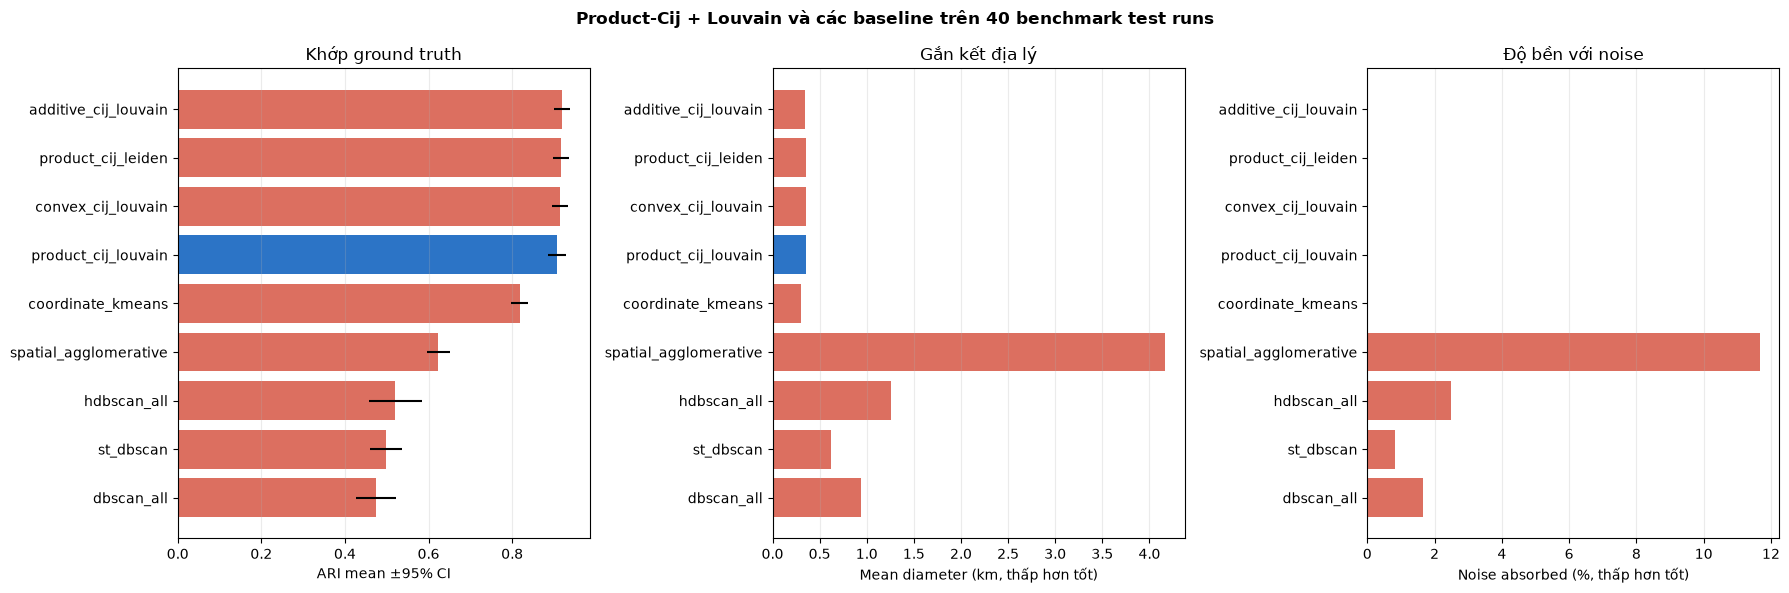

Đã lưu: /content/drive/MyDrive/Colab Notebooks/data/cij_baseline_benchmark_results/cij_baseline_benchmark.png


In [7]:
# Tổng hợp và kiểm định ghép cặp so với phương pháp đề xuất.
PRIMARY='product_cij_louvain'
summary=(test_df.groupby('method').agg(
    ari_mean=('ari','mean'),ari_std=('ari','std'),nmi_mean=('nmi','mean'),
    pair_f1_mean=('pair_f1','mean'),mean_diameter_km=('mean_diameter_km','mean'),
    max_diameter_km=('max_diameter_km','mean'),noise_absorbed_pct=('noise_absorbed_pct','mean'),
    runtime_seconds=('runtime_seconds','mean')).reset_index())
summary['ari_ci95']=1.96*summary['ari_std']/np.sqrt(40)
display(summary.sort_values('ari_mean',ascending=False))

rng=np.random.default_rng(20260812); comparisons=[]
primary=test_df[test_df.method==PRIMARY].set_index('run_id')
for method in METHODS:
    if method==PRIMARY:continue
    other=test_df[test_df.method==method].set_index('run_id'); delta=(primary.ari-other.ari).to_numpy()
    boot=np.mean(rng.choice(delta,size=(10000,len(delta)),replace=True),axis=1)
    try:p=float(wilcoxon(delta).pvalue) if np.any(delta!=0) else 1.0
    except ValueError:p=1.0
    comparisons.append({'baseline':method,'mean_delta_ari':float(delta.mean()),
      'ci95_low':float(np.quantile(boot,.025)),'ci95_high':float(np.quantile(boot,.975)),
      'wins':int(np.sum(delta>0)),'ties':int(np.sum(delta==0)),'losses':int(np.sum(delta<0)),
      'wilcoxon_p_raw':p})
comparison_df=pd.DataFrame(comparisons).sort_values('wilcoxon_p_raw')
# Holm adjustment cho nhiều baseline.
m=len(comparison_df); adjusted=np.maximum.accumulate(np.minimum(1.0,(m-np.arange(m))*comparison_df.wilcoxon_p_raw.to_numpy()))
comparison_df['wilcoxon_p_holm']=adjusted
display(comparison_df)
SUMMARY_PATH=RESULTS_ROOT/'benchmark_summary.csv'; COMP_PATH=RESULTS_ROOT/'paired_comparisons.csv'
summary.to_csv(SUMMARY_PATH,index=False); comparison_df.to_csv(COMP_PATH,index=False)

FIG_PATH=RESULTS_ROOT/'cij_baseline_benchmark.png'
order=summary.sort_values('ari_mean',ascending=True); colors=['#1565c0' if m==PRIMARY else '#d95f4f' for m in order.method]
fig,axes=plt.subplots(1,3,figsize=(18,6))
axes[0].barh(order.method,order.ari_mean,xerr=order.ari_ci95,color=colors,alpha=.9);axes[0].set(xlabel='ARI mean ±95% CI',title='Khớp ground truth')
axes[1].barh(order.method,order.mean_diameter_km,color=colors,alpha=.9);axes[1].set(xlabel='Mean diameter (km, thấp hơn tốt)',title='Gắn kết địa lý')
axes[2].barh(order.method,order.noise_absorbed_pct,color=colors,alpha=.9);axes[2].set(xlabel='Noise absorbed (%, thấp hơn tốt)',title='Độ bền với noise')
for ax in axes:ax.grid(axis='x',alpha=.25)
fig.suptitle('Product-Cij + Louvain và các baseline trên 40 benchmark test runs',fontweight='bold')
fig.tight_layout();fig.savefig(FIG_PATH,dpi=180,bbox_inches='tight');plt.show()
print('Đã lưu:',FIG_PATH)


## Cách kết luận

Không kết luận chỉ từ việc phương pháp nào đứng đầu ARI. Với mỗi baseline, xem `mean_delta_ari = ARI_product − ARI_baseline`:

- CI 95% hoàn toàn lớn hơn 0 và Holm-$p<0.05$: có bằng chứng product tốt hơn baseline đó về ARI trên benchmark này.
- CI chứa 0: chưa đủ bằng chứng khác biệt.
- CI hoàn toàn nhỏ hơn 0: product kém baseline đó về ARI.

Đồng thời phải đọc đường kính cụm và noise absorption. Nếu additive/baseline có ARI tương đương nhưng product tạo cụm gọn hơn, kết luận phù hợp là product có chất lượng cạnh tranh và lợi thế localization — không phải luôn chính xác hơn mọi thuật toán.


In [8]:
from google.colab import files
for path in [TUNING_PATH,CONFIG_PATH,TEST_PATH,SUMMARY_PATH,COMP_PATH,FIG_PATH]:
    files.download(str(path))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>